In [15]:
%matplotlib inline 
import matplotlib.pyplot as plt
import IPython.display as ipd

import os
os.chdir('/engram/nklab/pf2477/multimodal_encoder/')
!pwd

import sys
print(sys.executable)

import warnings
warnings.filterwarnings('ignore')

/engram/nklab/pf2477/multimodal_encoder
/engram/nklab/pf2477/multimodal_encoder/.pixi/envs/default/bin/python


In [16]:
from cneuro_dataset.cneuro_data import algonauts_dataset
from args import get_args_parser
parser = get_args_parser()
args = parser.parse_args(args=[])
print(args)
root_data_dir = '/engram/nklab/datasets/'

Namespace(ckpt_root='./ckpt', seed=42, epochs=15, batch_size=8, num_workers=2, pipeline_sanity_check=False, sanity_batches=2, lr=0.0001, weight_decay=0.0001, step_size=100, step_size_gamma=0.1, max_grad_norm=0.1, l2_reg=0.0, train_splits='friends-train-default', val_splits='friends-test-default', test_splits='movie10-ood-default', use_wandb=False, wandb_project='multimodal-encoder', wandb_run_name=None, resume=None, eval_only=False, save_checkpoints=False, save_test_predictions=False, save_test_movie_breakdown=False, save_test_causal_intervention=False, save_encoding_acc=True, subj=1, target_subj=1, readout_res='parcels', num_queries=1000, num_frames=16, num_parcels=1000, num_voxels=122721, modality=['video', 'audio', 'text'], video_backbone='metaclip', audio_backbone='whisper', text_backbone='metaclip', enc_layers=0, dec_layers=1, dim_feedforward=512, hidden_dim=256, dropout=0.1, nheads=8, pre_norm=1, enc_output_layer=-1, modality_dropout=0.2, attn_maps=False, attn_write_mode='batch',

In [17]:
from models.multimodel_backbone import BACKBONE_LIST
args.subj = 1
args.test_splits = ["life"]
args.backbone_list = BACKBONE_LIST
args.text_backbone = "llama"
args.video_backbone = "dino"
args.audio_backbone = "whisper"

args.readout_res = "voxels"
test_dataset = algonauts_dataset(args, include_splits=args.test_splits)
args.valid_voxel_mask = test_dataset.valid_voxel_mask if args.readout_res == "voxels" else None
args.masked_parcellation = test_dataset.masked_parcellation if args.readout_res == "voxels" else None

Adding font: Times New Roman Bold.ttf
Adding font: Times New Roman.ttf
Adding font: Times New Roman Bold Italic.ttf
Adding font: Times New Roman Italic.ttf
[fetch_atlas_schaefer_2018] Dataset found in /home/pf2477/nilearn_data/schaefer_2018

=== Subject 01 ===


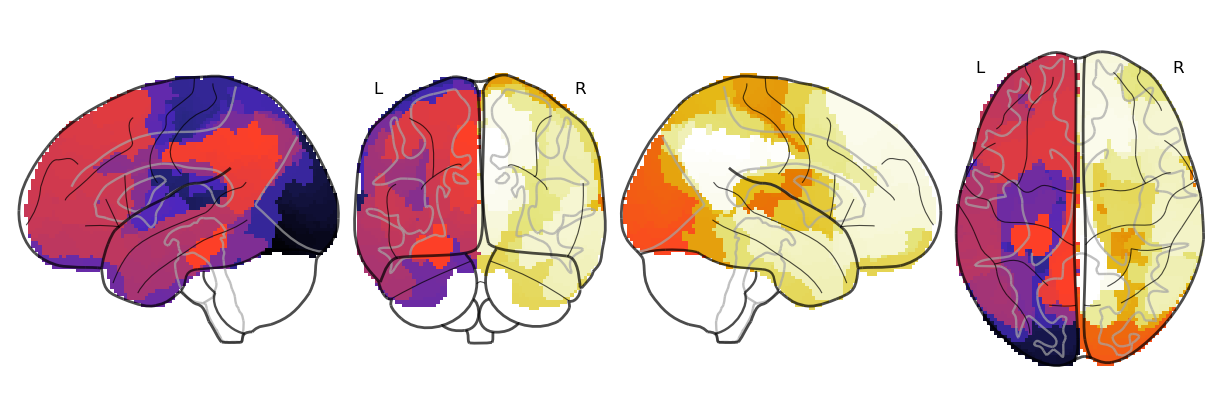

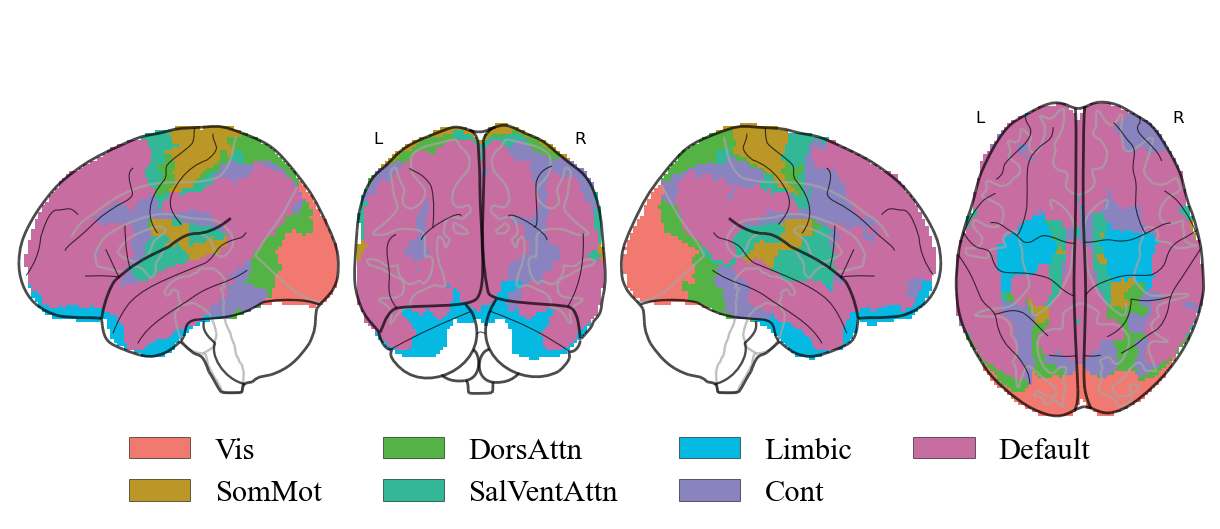

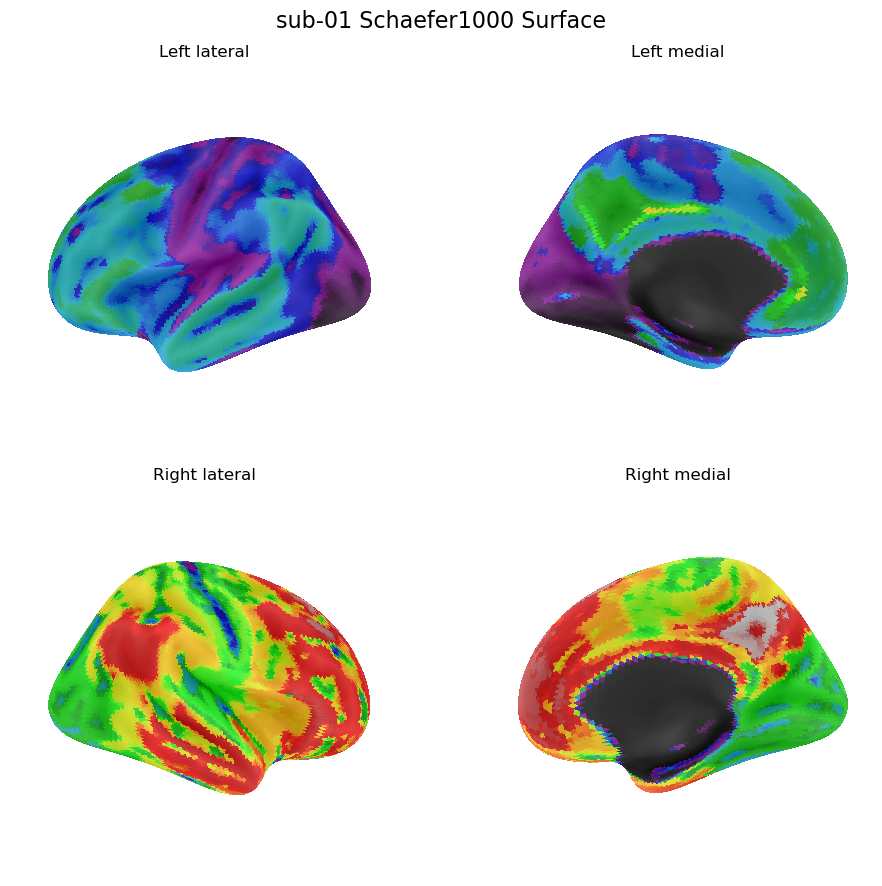

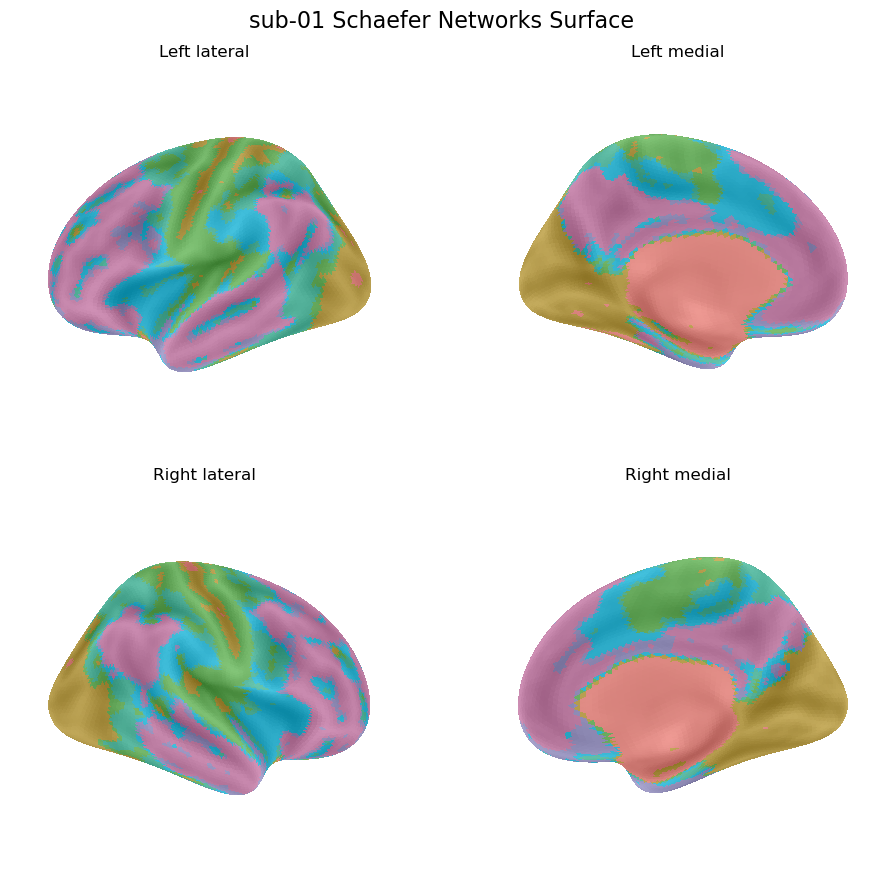

In [ ]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn import plotting, datasets, surface
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import matplotlib.font_manager as fm
import seaborn as sns

# Path to your font folder
font_dir = "/engram/nklab/pf2477/other/font/"

# Register all fonts in that folder
for font in os.listdir(font_dir):
    if font.startswith("Times New Roman"):
        print("Adding font:", font)
        fm.fontManager.addfont(os.path.join(font_dir, font))

# save_dir = Path("/engram/nklab/pf2477/multimodal_encoder/attn_map_analysis/roi_labels/")
# save_dir.mkdir(parents=True, exist_ok=True)
save_dir = None

root_data_dir = "/engram/nklab/datasets/algonauts_2025.competitors/fmri/"

subject2schaefer_path = {
    1: "sub-01/atlas/sub-01_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    2: "sub-02/atlas/sub-02_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    3: "sub-03/atlas/sub-03_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
    5: "sub-05/atlas/sub-05_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz",
}

def decode_label(x):
    return x.decode("utf-8") if isinstance(x, bytes) else str(x)

def parse_schaefer_label(label):
    # Example: 7Networks_LH_Vis_1
    parts = label.split("_")
    return {
        "schaefer_name": label,
        "hemi": parts[1] if len(parts) > 1 else "NA",
        "network": parts[2] if len(parts) > 2 else "NA",
        "subindex": parts[3] if len(parts) > 3 else "NA",
    }

def load_schaefer_labels(n_rois=1000, yeo_networks=7, resolution_mm=2):
    atlas = datasets.fetch_atlas_schaefer_2018(
        n_rois=n_rois,
        yeo_networks=yeo_networks,
        resolution_mm=resolution_mm,
    )
    labels = [decode_label(x) for x in atlas.labels]
    rows = []
    for parcel_id in range(1, len(labels)):
        parsed = parse_schaefer_label(labels[parcel_id])
        rows.append({"parcel_id": parcel_id, **parsed})
    return pd.DataFrame(rows), labels

def load_fsaverage(mesh="fsaverage5"):
    return datasets.fetch_surf_fsaverage(mesh=mesh)

def project_volume_to_surface(atlas_img, fsaverage):
    atlas_data = np.asarray(atlas_img.dataobj, dtype=np.float32)
    atlas_data = np.nan_to_num(atlas_data, nan=0.0)
    atlas_img = nib.Nifti1Image(atlas_data, affine=atlas_img.affine, header=atlas_img.header)

    textures = {}
    for hemi in ("left", "right"):
        texture = surface.vol_to_surf(
            atlas_img,
            getattr(fsaverage, f"pial_{hemi}"),
            interpolation="linear",
        )
        textures[hemi] = np.rint(np.nan_to_num(texture, nan=0.0)).astype(np.int32)
    return textures

def make_parcel_colormap(parcel_ids):
    n = len(parcel_ids)
    colors = plt.cm.gist_ncar(np.linspace(0, 1, n, endpoint=False))
    colors = np.vstack([
        np.array([[0.0, 0.0, 0.0, 0.0]]),
        colors,
    ])
    cmap = ListedColormap(colors)
    cmap.set_bad((0.0, 0.0, 0.0, 0.0))
    return cmap

def remap_texture_to_dense_labels(texture, parcel_ids):
    remapped = np.zeros_like(texture, dtype=np.int32)
    for dense_id, parcel_id in enumerate(parcel_ids, start=1):
        remapped[texture == parcel_id] = dense_id
    return remapped

def inspect_schaefer_volume(path):
    img = nib.load(path)
    data = img.get_fdata().astype(np.int32)
    labels = np.unique(data)

    # print("path:", path)
    # print("shape:", data.shape)
    # print("affine:\n", img.affine)
    # print("voxel sizes:", img.header.get_zooms()[:3])
    # print("unique labels:", len(labels))
    # print("min/max:", labels.min(), labels.max())
    # print("has all 1..1000:", set(range(1, 1001)).issubset(set(labels)))
    # print("missing parcels:", sorted(set(range(1, 1001)) - set(labels))[:20])

    return img, data

def plot_schaefer_volume(img, subj, out_dir=None):
    data = np.asarray(img.dataobj, dtype=np.float32)
    plot_data = data.copy()
    plot_data[plot_data == 0] = np.nan

    plot_img = nib.Nifti1Image(plot_data, affine=img.affine, header=img.header)

    fig = plt.figure(figsize=(12, 4), facecolor="white")

    display = plotting.plot_glass_brain(
        plot_img,
        display_mode="lyrz",
        # title=f"sub-{subj:02d} Schaefer-1000 parcels",
        # cmap="turbo",
        # cmap="gist_earth",
        # cmap="cubehelix",
        # cmap="CMRmap",
        cmap="nipy_spectral",
        colorbar=False,
        plot_abs=False,
        threshold=0.5,
        vmin=1,
        vmax=1000,
        black_bg=False,
        figure=fig,
    )

    for ax in display.axes.values():
        if hasattr(ax, "ax"):
            ax.ax.set_facecolor("white")
        else:
            ax.set_facecolor("white")

    fig.patch.set_facecolor("white")

    if out_dir is not None:
        out_file = Path(out_dir) / f"sub-{subj:02d}_schaefer1000_glass.png"
        display.savefig(str(out_file), dpi=300)
        print("saved:", out_file)

    plotting.show()

NETWORK_ORDER = [
    "Vis", "SomMot", "DorsAttn", "SalVentAttn",
    "Limbic", "Cont", "Default"
]

NETWORK_COLORS = [
        # "#4C78A8",  # Vis
        # "#F58518",  # SomMot
        # "#54A24B",  # DorsAttn
        # "#E45756",  # SalVentAttn
        # "#B279A2",  # Limbic
        # "#72B7B2",  # Cont
        # "#FF9DA6",  # Default
        # "#F27970",
        # "#BB9727",
        # "#54B345", 
        # "#32B897",
        # "#05B9E2",
        # "#8983BF",
        # "#C76DA2",
        # "#8ECFC9",
        # "#FFBE7A",
        # "#FA7F6F",
        # "#82B0D2",
        # "#BEB8DC",
        # "#999999",
        # "#E7DAD2",
        "#F27970",
        "#BB9727",
        "#54B345",
        "#32B897",
        "#05B9E2",
    "#8983BF",
    "#C76DA2",
]

NETWORK_CMAP = ListedColormap(NETWORK_COLORS)

def plot_network_volume(schaefer_img, schaefer_data, labels_df, subj, out_dir=None):
    network_to_id = {net: i + 1 for i, net in enumerate(NETWORK_ORDER)}

    parcel_to_network_id = dict(
        zip(labels_df["parcel_id"], labels_df["network"].map(network_to_id))
    )

    network_data = np.full_like(schaefer_data, np.nan, dtype=np.float32)
    
    for parcel_id, network_id in parcel_to_network_id.items():
        if pd.isna(network_id):
            continue
        network_data[schaefer_data == parcel_id] = float(network_id)

    network_img = nib.Nifti1Image(
        network_data,
        affine=schaefer_img.affine,
        header=schaefer_img.header,
    )

    fig = plt.figure(figsize=(12, 5), facecolor="white")

    display = plotting.plot_glass_brain(
        network_img,
        display_mode="lyrz",
        # title=f"sub-{subj:02d} Schaefer parcels by Yeo 7-network",
        cmap=NETWORK_CMAP,
        colorbar=False,
        plot_abs=False,
        threshold=0.5,
        vmin=1,
        vmax=7,
        black_bg=False,
        figure=fig,
    )

    for ax in display.axes.values():
        if hasattr(ax, "ax"):
            ax.ax.set_facecolor("white")
        else:
            ax.set_facecolor("white")

    fig.patch.set_facecolor("white")

    legend_handles = [
        Patch(facecolor=NETWORK_COLORS[i], edgecolor="black", linewidth=0.4, label=NETWORK_ORDER[i])
        for i in range(len(NETWORK_ORDER))
    ]

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, -0.05),
        prop={"family": "Times New Roman", "size": 22},
    )

    if out_dir is not None:
        out_file = Path(out_dir) / f"sub-{subj:02d}_schaefer_networks_glass.png"
        display.savefig(str(out_file), dpi=300)
        print("saved:", out_file)

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
    plt.show()

    return network_img, network_to_id

def plot_schaefer_surface_roi(
    atlas_img,
    subj,
    fsaverage,
    hemi="both",
    view="both",
    cmap="nipy_spectral",
    parcel_cmap=False,
    vmax=None,
    out_dir=None,
    out_stem="schaefer_surface",
):
    hemi_list = ["left", "right"] if hemi == "both" else [hemi]
    view_list = ["lateral", "medial"] if view == "both" else [view]
    textures = project_volume_to_surface(atlas_img, fsaverage)
    if parcel_cmap:
        atlas_data = np.asarray(atlas_img.dataobj, dtype=np.int32)
        parcel_ids = sorted(int(pid) for pid in np.unique(atlas_data) if pid > 0)
        cmap = make_parcel_colormap(parcel_ids)
        vmax = len(parcel_ids)
    else:
        parcel_ids = None

    fig, axes = plt.subplots(
        len(hemi_list),
        len(view_list),
        figsize=(5 * len(view_list), 4.5 * len(hemi_list)),
        subplot_kw={"projection": "3d"},
        facecolor="white",
    )
    axes = np.array(axes, dtype=object)
    if axes.ndim == 0:
        axes = axes.reshape(1, 1)
    elif axes.ndim == 1:
        if len(hemi_list) == 1:
            axes = axes.reshape(1, -1)
        else:
            axes = axes.reshape(-1, 1)

    for row, hemi_name in enumerate(hemi_list):
        for col, view_name in enumerate(view_list):
            ax = axes[row, col]
            roi_map = textures[hemi_name]
            if parcel_ids is not None:
                roi_map = remap_texture_to_dense_labels(roi_map, parcel_ids)
            plotting.plot_surf_roi(
                surf_mesh=getattr(fsaverage, f"infl_{hemi_name}"),
                roi_map=roi_map,
                hemi=hemi_name,
                view=view_name,
                bg_map=getattr(fsaverage, f"sulc_{hemi_name}"),
                figure=fig,
                axes=ax,
                cmap=cmap,
                colorbar=False,
                bg_on_data=True,
                vmax=vmax,
            )
            ax.set_title(f"{hemi_name.title()} {view_name}", fontsize=12)

    title = out_stem.replace("_", " ").title()
    fig.suptitle(f"sub-{subj:02d} {title}", fontsize=16, y=0.98)
    plt.tight_layout()

    if out_dir is not None:
        out_file = Path(out_dir) / f"sub-{subj:02d}_{out_stem}.png"
        fig.savefig(out_file, dpi=300, bbox_inches="tight")
        print("saved:", out_file)

    plt.show()

def save_parcel_label_table(labels_df, subj, out_dir):
    out_file = Path(out_dir) / f"sub-{subj:02d}_schaefer1000_labels.tsv"
    labels_df.to_csv(out_file, sep="\t", index=False)
    print("saved:", out_file)

labels_df, schaefer_labels = load_schaefer_labels(
    n_rois=1000,
    yeo_networks=7,
    resolution_mm=2,
)
fsaverage = load_fsaverage(mesh="fsaverage5")

for subj in [1, 2, 3, 5][:1]:
    print(f"\n=== Subject {subj:02d} ===")
    schaefer_path = os.path.join(root_data_dir, subject2schaefer_path[subj])

    schaefer_img, schaefer_data = inspect_schaefer_volume(schaefer_path)
    # save_parcel_label_table(labels_df, subj, save_dir)

    plot_schaefer_volume(
        schaefer_img,
        subj=subj,
        out_dir=save_dir,
    )

    network_img, network_to_id = plot_network_volume(
        schaefer_img,
        schaefer_data,
        labels_df,
        subj=subj,
        out_dir=save_dir,
    )

    plot_schaefer_surface_roi(
        schaefer_img,
        subj=subj,
        fsaverage=fsaverage,
        hemi="both",
        view="both",
        cmap="nipy_spectral",
        parcel_cmap=True,
        vmax=1000,
        out_dir=save_dir,
        out_stem="schaefer1000_surface",
    )

    plot_schaefer_surface_roi(
        network_img,
        subj=subj,
        fsaverage=fsaverage,
        hemi="both",
        view="both",
        cmap=NETWORK_CMAP,
        vmax=len(NETWORK_ORDER),
        out_dir=save_dir,
        out_stem="schaefer_networks_surface",
    )